# Domain analysis — adapted from Miletić & Falk (LREC 2026)

Adapts `lexical_analysis/analysis_main.ipynb` and `analysis_ngrams.ipynb` to a
4-domain setting: **arxiv abstracts, congress politics, human WP stories, WSJ news**.

The paper compares two corpora (`cacl_t1` = naturalistic, `cacl_t2` = LLM-paraphrased).
Here we compare arbitrary domain pairs. Frequency + log-likelihood data has been
pre-computed in `outputs_lexical/` by `run_lexical_on_domains.sh`:

- `<a>_vs_<b>_1grams_freqs_inner_ll.parquet` for all 6 unordered pairs
- `<a>_vs_<b>_5grams_freqs_inner_ll.parquet` (same)

**Not included** (would require running word2vec / clustering on each domain;
unreliable with only 100 documents per domain):

- Neighborhood density (`delta_nn` analyses) → cells in `analysis_main.ipynb`
  that compute `corr_ll_nn_df` and plot signed-LL vs delta_nn are omitted.
- Contextualized cluster analysis (`analysis_clusters.ipynb`).

Sections:
1. Setup — choose a pair (corpus1 = base, corpus2 = target)
2. Significant LL counts (content words)
3. Top frequency shifts per POS — table + barplot
4. 5-gram top shifts
5. Full pairwise summary across all 6 domain pairs


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context('talk')
pd.set_option('display.max_columns', 40)

LEX_DIR = Path('../outputs_lexical')
DOMAINS = [
    'arxiv_abstracts_100',
    'congress_politics_2026_lines_100',
    'human_wp_stories_100',
    'news_wsj_100',
]
SHORT = {
    'arxiv_abstracts_100': 'arxiv',
    'congress_politics_2026_lines_100': 'politics',
    'human_wp_stories_100': 'stories',
    'news_wsj_100': 'wsj',
}

def ll_path(a: str, b: str, n: int = 1) -> Path:
    """Return the LL parquet for the pair, regardless of order."""
    cand = LEX_DIR / f'{a}_vs_{b}_{n}grams_freqs_inner_ll.parquet'
    if cand.exists():
        return cand, False  # not swapped
    cand2 = LEX_DIR / f'{b}_vs_{a}_{n}grams_freqs_inner_ll.parquet'
    if cand2.exists():
        return cand2, True   # swapped: corpus1 is b, corpus2 is a
    raise FileNotFoundError(cand)

def load_pair(a: str, b: str, n: int = 1) -> pd.DataFrame:
    """Load LL parquet with column convention: t1 = a (base), t2 = b (target).
    If the on-disk file has the opposite order, columns are renamed to honor
    the (a, b) convention requested by the caller."""
    p, swapped = ll_path(a, b, n)
    df = pd.read_parquet(p)
    if swapped:
        df = df.rename(columns={
            'freq1': 'freq2_tmp', 'freq2': 'freq1',
            'freq_norm1': 'freq_norm2_tmp', 'freq_norm2': 'freq_norm1',
            'ratio_t1': 'ratio_t2_tmp', 'ratio_t2': 'ratio_t1',
            'logratio_t1': 'logratio_t2_tmp', 'logratio_t2': 'logratio_t1',
        })
        df = df.rename(columns={c.replace('_tmp', ''): c for c in df.columns if c.endswith('_tmp')})
        df = df.rename(columns={'freq2_tmp': 'freq2', 'freq_norm2_tmp': 'freq_norm2',
                                'ratio_t2_tmp': 'ratio_t2', 'logratio_t2_tmp': 'logratio_t2'})
    return df

# critical value for chi-square 1 df at p < 0.0001 (paper's threshold)
LL_CRIT = 15.13


## 1. Pick a pair

Change `BASE` and `TARGET` to inspect any domain pair. The signed-LL convention follows
the paper: positive = word is **over-represented in target** relative to base.


In [10]:
BASE = 'news_wsj_100'         # corpus1 / t1
TARGET = 'human_wp_stories_100'  # corpus2 / t2

df_ll = load_pair(BASE, TARGET, n=1)
print(f'Loaded {len(df_ll)} shared 1-grams ({SHORT[BASE]} vs {SHORT[TARGET]})')
df_ll.head()


Loaded 2395 shared 1-grams (wsj vs stories)


,target,lemma,pos,freq2,freq_norm2,freq1,freq_norm1,ratio_t1,ratio_t2,logratio_t2,logratio_t1,ll
0,.:PUNCT,.,PUNCT,3486,56830.779263,2106,37982.217253,0.668339,1.496247,0.581348,-0.581348,218.971664
1,the:DET,the,DET,2828,46103.684382,2623,47306.436777,1.026088,0.974575,-0.037154,0.037154,0.902240
2,",:PUNCT",",",PUNCT,2536,41343.332246,2697,48641.044601,1.176515,0.849968,-0.234520,0.234520,34.556878
3,be:AUX,be,AUX,1818,29638.082817,1256,22652.262521,0.764296,1.308394,0.387797,-0.387797,54.399367
4,i:PRON,i,PRON,1712,27910.009782,89,1605.136437,0.057511,17.387936,4.120015,-4.120015,1628.521575


## 2. Significant log-likelihood (content words)

Mirrors the paper's content-word filter: keep `NOUN/ADJ/VERB/ADV` lemmas, alphabetic, ≥3 chars.
LL > 15.13 is "significant" (chi-square critical value at p < 0.0001, 1 df).


In [3]:
pos_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
min_chars = 3

df_cw = df_ll[(df_ll['pos'].isin(pos_tags)) &
              (df_ll['lemma'].str.isalpha()) &
              (df_ll['lemma'].str.len() >= min_chars)].copy()

df_cw['ll_signif'] = (df_cw['ll'] > LL_CRIT).astype(int)
# Signed LL: positive if word is over-represented in target (ratio_t2 > 1)
df_cw['signed_ll'] = np.where(df_cw['ratio_t2'] < 1, -df_cw['ll'], df_cw['ll'])

n_total = len(df_cw)
n_signif = int(df_cw['ll_signif'].sum())
n_up = int(((df_cw['ll_signif'] == 1) & (df_cw['ratio_t2'] > 1)).sum())
n_down = n_signif - n_up
print(f'Content words shared by both corpora: {n_total}')
print(f'  LL > {LL_CRIT}: {n_signif} ({100*n_signif/n_total:.1f}%)')
print(f'   of which over-represented in {SHORT[TARGET]} (target): {n_up}')
print(f'   under-represented in {SHORT[TARGET]} (i.e. higher in {SHORT[BASE]}): {n_down}')


Content words shared by both corpora: 1990
  LL > 15.13: 177 (8.9%)
   of which over-represented in stories (target): 79
   under-represented in stories (i.e. higher in wsj): 98


## 3. Top frequency shifts per POS

Equivalent to the paper's "strongest changes in frequency" plot.
Top-N rising and falling words for each POS.


In [4]:
def top_shifts(df, topn=10):
    subs = []
    for pos in pos_tags:
        sub = df.loc[(df['pos'] == pos) &
                     (df['lemma'].str.isalpha()) &
                     (df['lemma'].str.len() >= min_chars)].sort_values('ll', ascending=False)
        subs.append(sub[sub['ratio_t2'] > 1].head(topn))
        subs.append(sub[sub['ratio_t2'] < 1].head(topn))
    out = pd.concat(subs, ignore_index=True)
    out['signed_ll'] = np.where(out['ratio_t2'] < 1, -out['ll'], out['ll'])
    out['direction'] = np.where(out['signed_ll'] > 0, f'over in {SHORT[TARGET]}', f'over in {SHORT[BASE]}')
    return out

topdf = top_shifts(df_ll, topn=10)
topdf[['lemma', 'pos', 'freq1', 'freq2', 'll', 'signed_ll']].to_string()
print(topdf.head(20).to_string(index=False))


       target    lemma  pos  freq2  freq_norm2  freq1  freq_norm1  ratio_t1  ratio_t2  logratio_t2  logratio_t1         ll   signed_ll       direction
     man:NOUN      man NOUN    149 2429.083795     17  306.599095  0.126220  7.922671     2.985987    -2.985987 107.540770  107.540770 over in stories
     eye:NOUN      eye NOUN     95 1548.744702      4   72.140963  0.046580 21.468312     4.424137    -4.424137  94.797352   94.797352 over in stories
    face:NOUN     face NOUN     84 1369.416368      6  108.211445  0.079020 12.655005     3.661636    -3.661636  73.030179   73.030179 over in stories
    door:NOUN     door NOUN     50  815.128790      2   36.070482  0.044251 22.598223     4.498137    -4.498137  50.417200   50.417200 over in stories
   voice:NOUN    voice NOUN     43  701.010760      1   18.035241  0.025727 38.868944     5.280546    -5.280546  47.321456   47.321456 over in stories
   light:NOUN    light NOUN     40  652.103032      1   18.035241  0.027657 36.157157     5.17

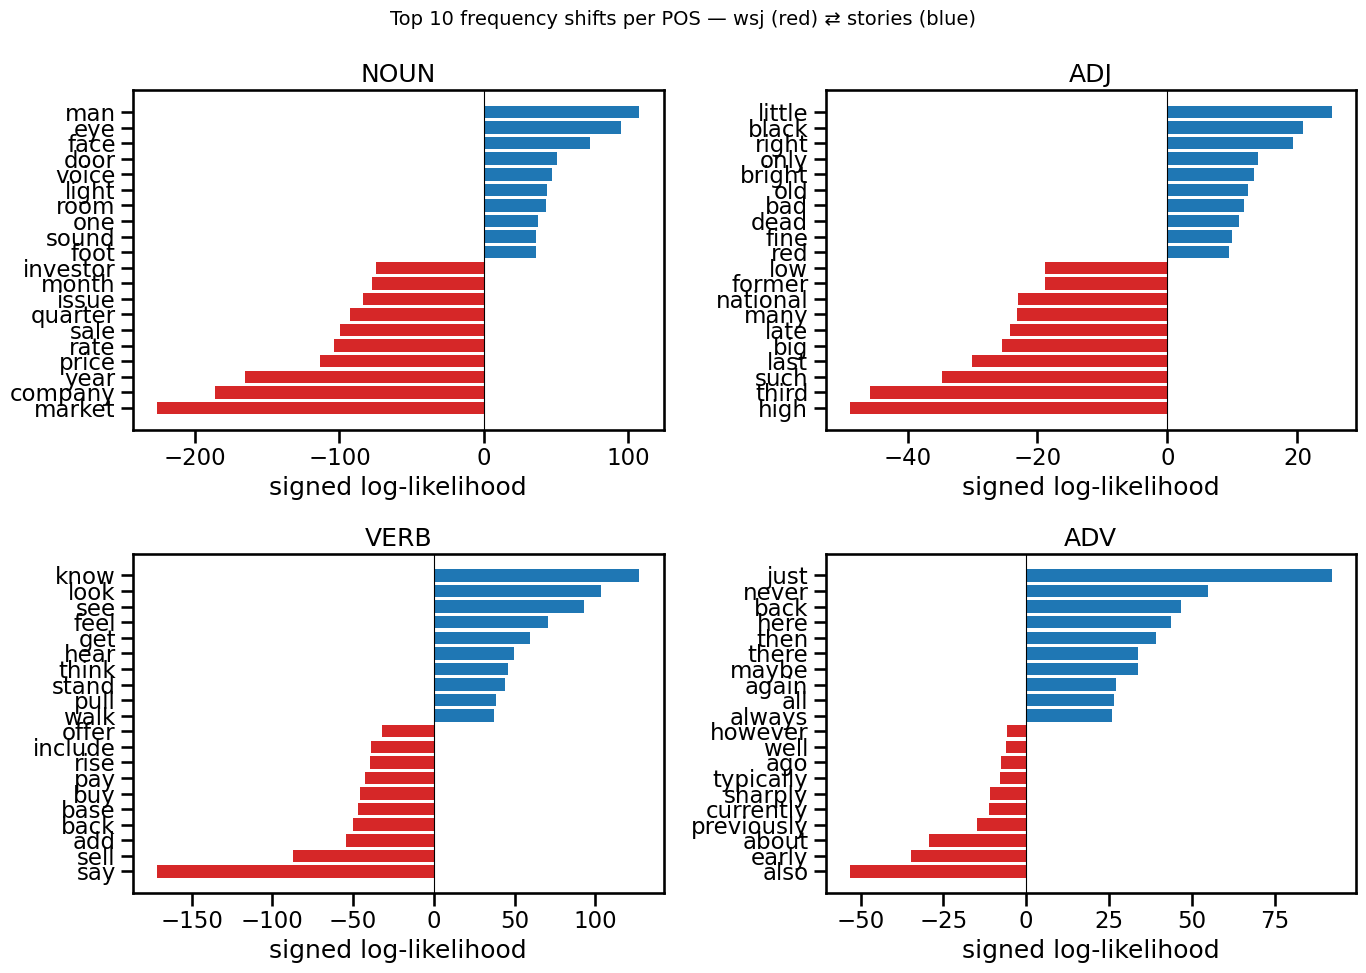

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
for ax, pos in zip(axes.flat, pos_tags):
    sub = topdf[topdf['pos'] == pos].sort_values('signed_ll')
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in sub['signed_ll']]
    ax.barh(sub['lemma'], sub['signed_ll'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'{pos}')
    ax.set_xlabel('signed log-likelihood')
fig.suptitle(f'Top 10 frequency shifts per POS — {SHORT[BASE]} (red) ⇄ {SHORT[TARGET]} (blue)',
             fontsize=14)
fig.tight_layout()
plt.show()


## 4. 5-gram shifts

Equivalent to `analysis_ngrams.ipynb`. We don't filter by POS here — just rank by raw LL.


In [6]:
df_ng = load_pair(BASE, TARGET, n=5)
df_ng['signed_ll'] = np.where(df_ng['ratio_t2'] < 1, -df_ng['ll'], df_ng['ll'])
df_ng_signif = df_ng[df_ng['ll'] > LL_CRIT]
print(f'5-gram types shared by both: {len(df_ng)}  |  significant: {len(df_ng_signif)}')

up = df_ng_signif[df_ng_signif['ratio_t2'] > 1].nlargest(15, 'll')[['lemma', 'freq1', 'freq2', 'll']]
down = df_ng_signif[df_ng_signif['ratio_t2'] < 1].nlargest(15, 'll')[['lemma', 'freq1', 'freq2', 'll']]
print(f'\nTop 15 5-grams over-represented in {SHORT[TARGET]}:')
print(up.to_string(index=False))
print(f'\nTop 15 5-grams over-represented in {SHORT[BASE]}:')
print(down.to_string(index=False))


5-gram types shared by both: 22  |  significant: 0

Top 15 5-grams over-represented in stories:
Empty DataFrame
Columns: [lemma, freq1, freq2, ll]
Index: []

Top 15 5-grams over-represented in wsj:
Empty DataFrame
Columns: [lemma, freq1, freq2, ll]
Index: []


## 5. Summary across all 6 domain pairs

For each unordered pair, count significant content-word LL events and report how many lean
toward each side. Gives a quick lexical-distance overview without picking a single pair.


In [7]:
from itertools import combinations

rows = []
for a, b in combinations(DOMAINS, 2):
    df = load_pair(a, b, n=1)
    cw = df[(df['pos'].isin(pos_tags)) &
            (df['lemma'].str.isalpha()) &
            (df['lemma'].str.len() >= min_chars)]
    sig = cw[cw['ll'] > LL_CRIT]
    rows.append({
        'pair': f'{SHORT[a]} ↔ {SHORT[b]}',
        'shared_content_words': len(cw),
        'signif_ll': len(sig),
        'pct_signif': round(100 * len(sig) / max(len(cw), 1), 1),
        f'over_in_{SHORT[a]}': int((sig['ratio_t2'] < 1).sum()),
        f'over_in_{SHORT[b]}': int((sig['ratio_t2'] > 1).sum()),
        'mean_abs_ll_signif': round(sig['ll'].mean(), 1),
    })
summary = pd.DataFrame(rows)
summary


,pair,shared_content_words,signif_ll,pct_signif,over_in_arxiv,over_in_politics,mean_abs_ll_signif,over_in_stories,over_in_wsj
0,arxiv ↔ politics,602,51,8.5,38.0,13.0,31.8,NaN,NaN
1,arxiv ↔ stories,885,119,13.4,99.0,NaN,36.7,20.0,NaN
2,arxiv ↔ wsj,964,83,8.6,73.0,NaN,36.0,NaN,10.0
3,politics ↔ stories,1106,95,8.6,NaN,62.0,37.8,33.0,NaN
4,politics ↔ wsj,1342,98,7.3,NaN,54.0,32.2,NaN,44.0
5,stories ↔ wsj,1990,177,8.9,NaN,NaN,39.4,79.0,98.0


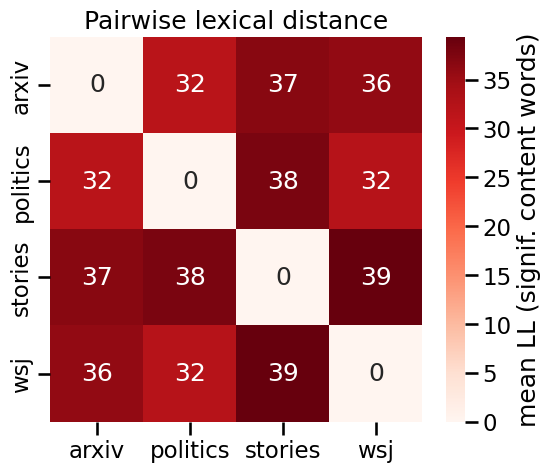

In [8]:
# Pairwise "lexical distance" heatmap: mean abs LL for significant content words
short_names = [SHORT[d] for d in DOMAINS]
mat = pd.DataFrame(0.0, index=short_names, columns=short_names)
for a, b in combinations(DOMAINS, 2):
    df = load_pair(a, b, n=1)
    cw = df[(df['pos'].isin(pos_tags)) &
            (df['lemma'].str.isalpha()) &
            (df['lemma'].str.len() >= min_chars)]
    sig = cw[cw['ll'] > LL_CRIT]
    val = float(sig['ll'].mean()) if len(sig) else 0.0
    mat.loc[SHORT[a], SHORT[b]] = val
    mat.loc[SHORT[b], SHORT[a]] = val

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(mat, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'mean LL (signif. content words)'}, ax=ax)
ax.set_title('Pairwise lexical distance')
plt.show()
